
# Week 1 – Exploratory Data Analysis (EDA)

Dataset used: **Titanic dataset**  



## Day 1 – Program Orientation & Data Understanding

### Learning Objectives
- Understand the role of EDA in Data Science
- Load and inspect datasets
- Understand data types, schema, and business context



### 1. What is EDA?


In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


### 2. Loading the Dataset

In [3]:
url = "titanic.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)


### 3. Dataset Overview
Key questions:
- How many rows & columns?
- What does each column represent?


In [5]:

df.shape


(891, 12)

In [6]:

df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



### 4. Understanding Data Types
- Numerical vs Categorical
- Continuous vs Discrete


In [9]:

df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### Exercise
1. Identify numerical and categorical columns
2. Which column could be the target?
3. Which columns might leak information?



## Day 2 – Relationship Analysis (4.5 hrs)

### Learning Objectives
- Perform univariate analysis
- Perform bivariate & multivariate analysis
- Interpret visualizations


### 1. Univariate Analysis
Examines a single variable at a time to describe its distribution, central tendency (mean, median, mode), and variability

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


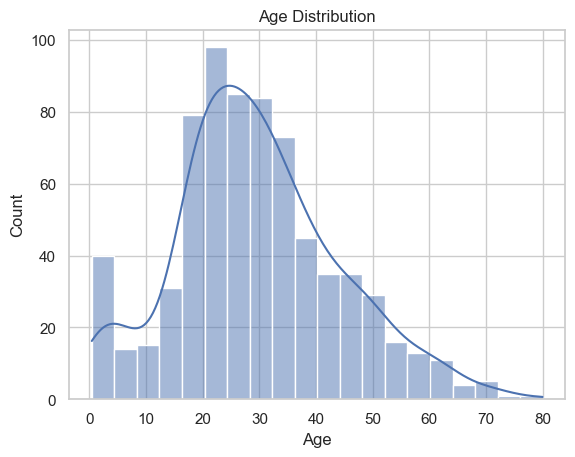

In [11]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


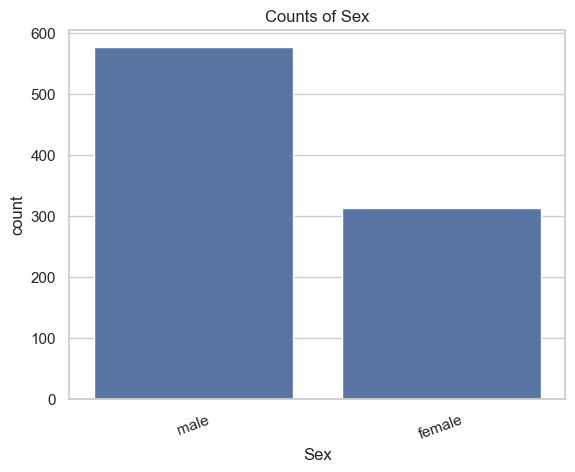

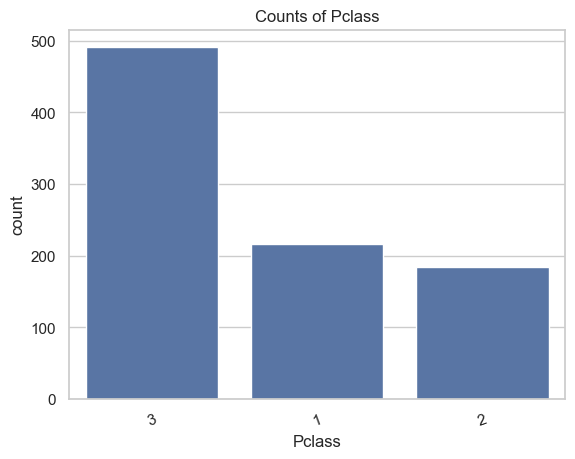

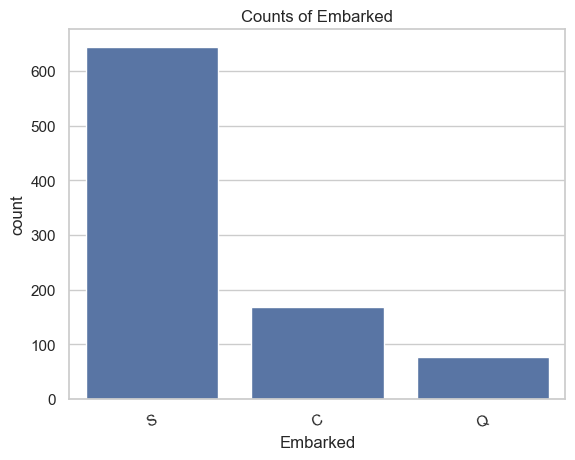

In [12]:

# Categorical distributions
for c in ["Sex", "Pclass", "Embarked"]:
    plt.figure()
    sns.countplot(x=c, data=df, order=df[c].value_counts().index)
    plt.title(f"Counts of {c}")
    plt.xticks(rotation=20)
    plt.show()


### 2. Bivariate Analysis
Examines the relationship between exactly two variables, determining the strength and direction of their association

In [13]:
target = "Survived"
df[target].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

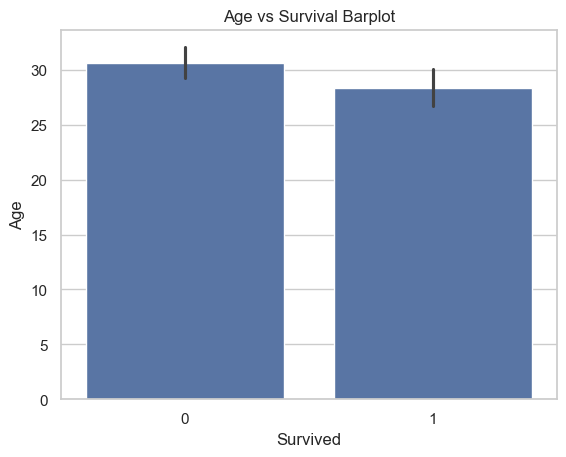

In [14]:
sns.barplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival Barplot")
plt.show()


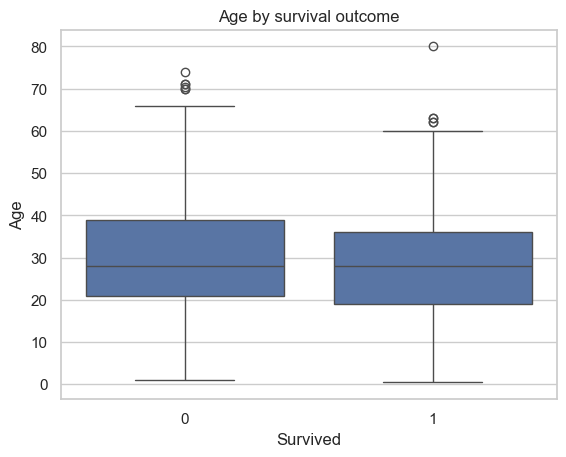

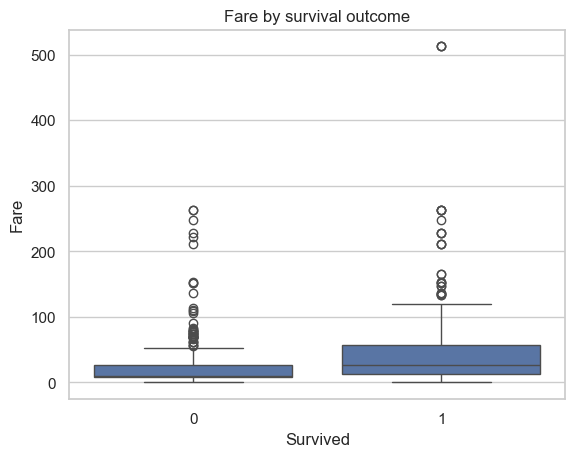

In [15]:
# Numeric feature vs target
for c in ["Age", "Fare"]:
    plt.figure()
    sns.boxplot(x=target, y=c, data=df)
    plt.title(f"{c} by survival outcome")
    plt.show()


### 3. Multivariate Analysis
Used to analyze data with more than two variables simultaneously, aiming to uncover complex patterns, relationships, and dependencies that univariate or bivariate methods miss, providing a more comprehensive understanding of the underlying structure

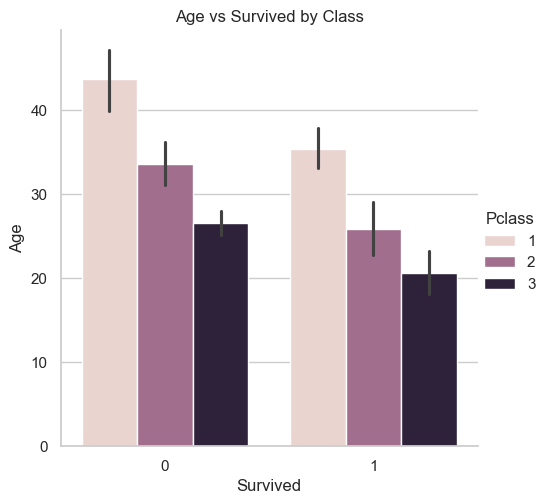

In [16]:
sns.catplot(x="Survived", y="Age", hue="Pclass", kind="bar", data=df)
plt.title('Age vs Survived by Class')
plt.show()

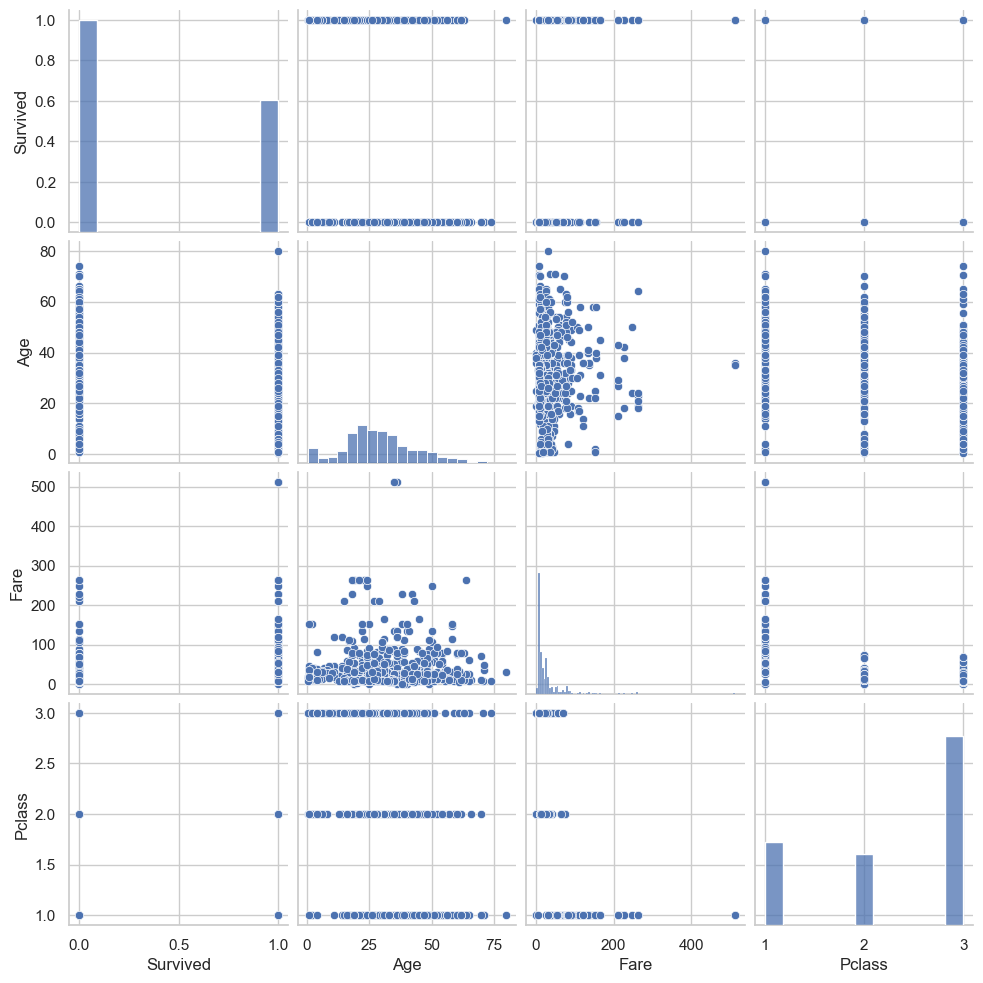

In [17]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']])
plt.show()

## 4. Outliers
Outliers can:
 - Inflate or hide correlations
 - Stretch axes and hide patterns
 - Dominate model coefficients
We must see them before we decide what to do.

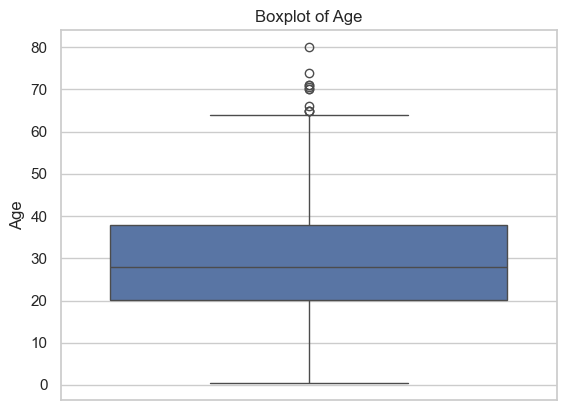

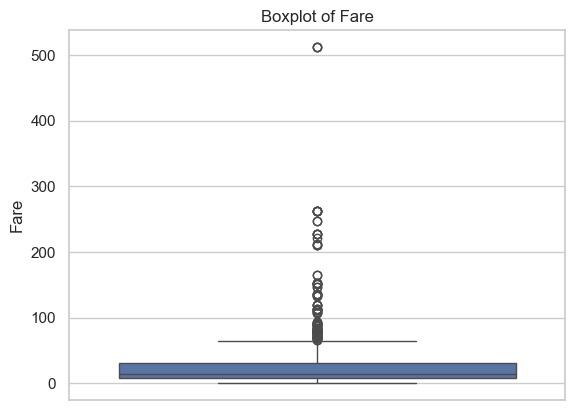

In [18]:
# Boxplots to surface outliers
for c in ["Age", "Fare"]:
    plt.figure()
    sns.boxplot(y=df[c])
    plt.title(f"Boxplot of {c}")
    plt.show()


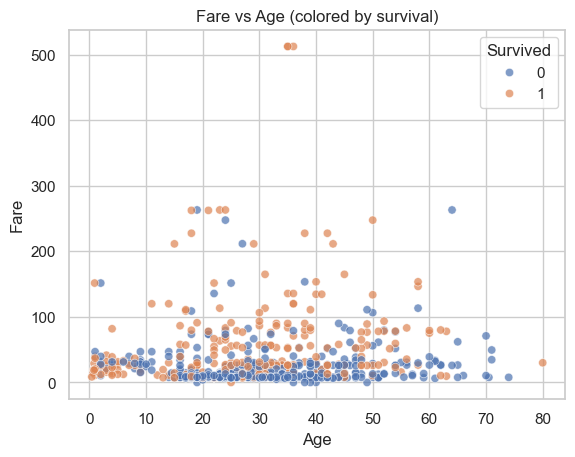

In [19]:
# Scatter plot to show bivariate outliers
plt.figure()
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.7)
plt.title("Fare vs Age (colored by survival)")
plt.show()


## 5. Correlation & Numeric–Numeric Relationships

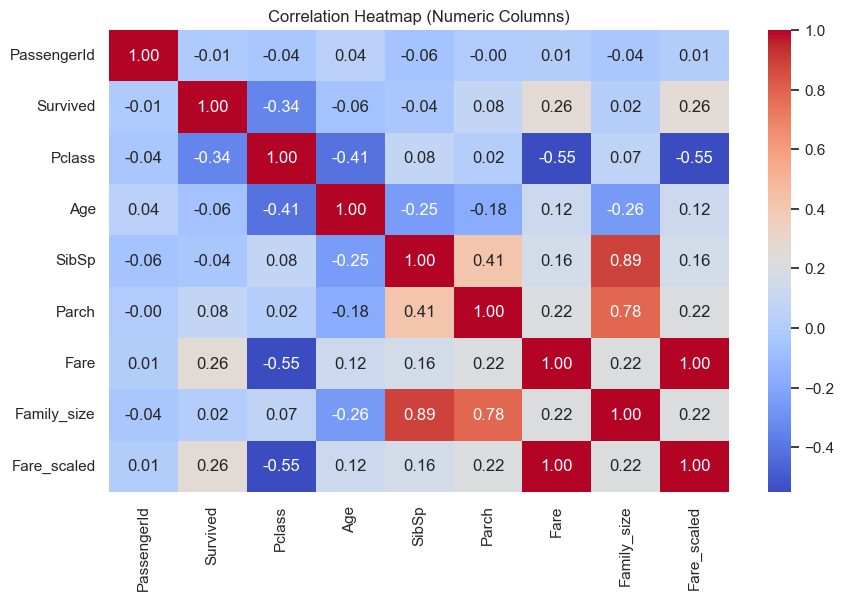

In [53]:
num = df.select_dtypes(include=np.number)
corr = num.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()



## Day 3 – Data Cleaning

### Learning Objectives
- Identify missing values
- Apply imputation strategies
- Handle duplicates & invalid data


In [32]:

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 1. Missing Data Strategies
- Drop
- Mean / Median
- Mode
- Domain-based


In [35]:

#df["Age"].fillna(df["Age"].median(), inplace=True) #just median, but won't make much sense

#Group based median
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)


In [ ]:
#Only 2 missing, so can easily impute with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

Cabin (687 missing, mostly empty). So Cabin is too sparse to impute meaningfully. 
Options:
 - Drop it completely
 - Convert to HasCabin feature - This would be a better option as having a cabin may correlate with wealth & survival

### 2. Duplicates

In [ ]:

df.duplicated().sum()

0


## Day 4 – Feature Engineering & Transformations

### Learning Objectives
- Create new features
- Apply scaling & transformations


### 1. Feature Creation

In [39]:

#Combines Sibling/Spouse and Parent/Children to understand the family size
df["Family_size"] = df["SibSp"] + df["Parch"] + 1 
df[["SibSp", "Parch", "Family_size"]].head()


,SibSp,Parch,Family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


Some common feature creation strategies:

1. **Arithmetic combinations**  
   - sums, differences, ratios, percentages  
   - e.g. `family_size = sibsp + parch + 1`

2. **Counts / frequencies**  
   - count of events, frequency in group  
   - e.g. number of prior purchases

3. **Bucketization / binning**  
   - convert continuous to ordered categories  
   - e.g. age bands, income brackets

4. **Interactions**  
   - combine two variables to capture their joint effect  
   - e.g. `sex × class`

5. **Flags / indicators**  
   - boolean columns for meaningful conditions  
   - e.g. `is_child`, `has_cabin_info`

6. **Aggregations over groups**  
   - mean/sum/count per group  
   - e.g. average fare per embark port (careful with leakage!)

7. **Date/time-based features**  
   - day-of-week, time-of-day, time since event, etc. (not used here, but critical in real data)

### 2. Feature Transformations - Log, Scaling, Normalization

In [55]:
# Check skew of fare
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

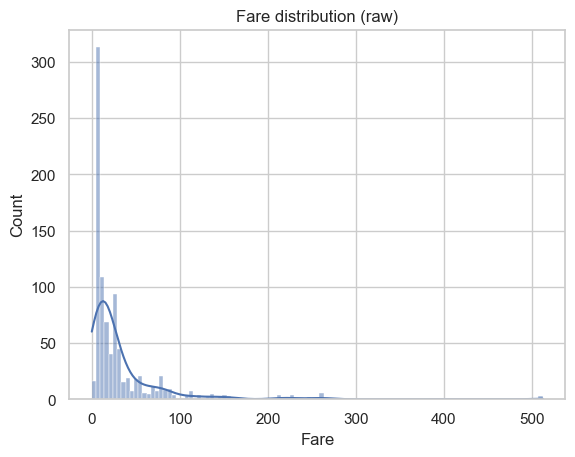

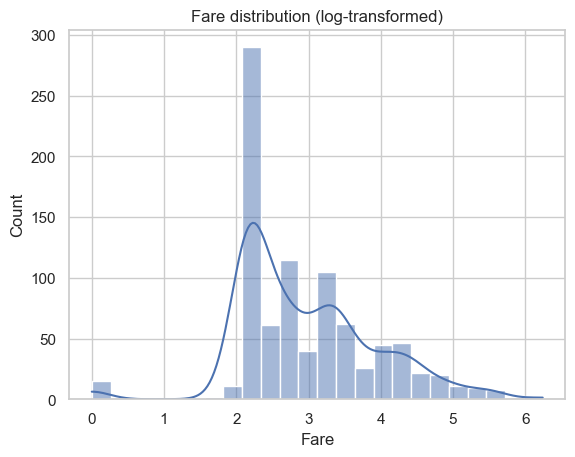

In [56]:

plt.figure()
sns.histplot(df["Fare"], kde=True)
plt.title("Fare distribution (raw)")
plt.show()

plt.figure()
sns.histplot(np.log1p(df["Fare"]), kde=True)
plt.title("Fare distribution (log-transformed)")
plt.show()


In [ ]:

#You compare scalers by model performance, not by plots

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df["Fare_std"] = scaler_std.fit_transform(df[["Fare"]])
df["Fare_mm"] = scaler_mm.fit_transform(df[["Fare"]])

df[["Fare","Fare_std","Fare_mm"]].head()


,Fare,Fare_std,Fare_mm
0,7.2500,-0.502445,0.014151
1,71.2833,0.786845,0.139136
2,7.9250,-0.488854,0.015469
3,53.1000,0.420730,0.103644
4,8.0500,-0.486337,0.015713



### Exercise
- Create at least 2 new features
- Scale numerical columns



## Day 5 – Basic Statistics

### Learning Objectives
- Understand distributions
- Perform hypothesis testing


### 1. Descriptive Statistics

In [42]:

df["Fare"].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

### 2. Probability Distributions

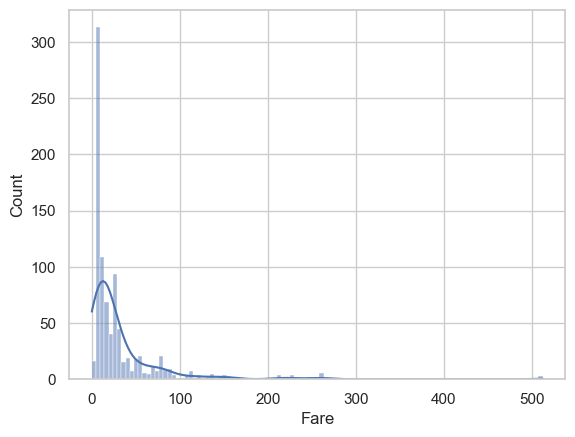

In [43]:

sns.histplot(df["Fare"], kde=True)
plt.show()


### 3. Hypothesis Testing

1. **Two-sample t-test** (or non-parametric alternative)  
   Compare mean fares for survived vs not survived.

2. **Proportions z-test**  
   Compare survival proportions between males and females.

3. **Chi-square test of independence**  
   Check association between `class` and `survived`.

### Two-Sample t-Test: Fare by Survival

In [65]:
fare_surv = df.loc[df["Survived"] == 1, "Fare"]
fare_not = df.loc[df["Survived"] == 0, "Fare"]

fare_surv.describe(), fare_not.describe()


(count    342.000000
 mean      48.395408
 std       66.596998
 min        0.000000
 25%       12.475000
 50%       26.000000
 75%       57.000000
 max      512.329200
 Name: Fare, dtype: float64,
 count    549.000000
 mean      22.117887
 std       31.388207
 min        0.000000
 25%        7.854200
 50%       10.500000
 75%       26.000000
 max      263.000000
 Name: Fare, dtype: float64)

In [67]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(fare_surv, fare_not, equal_var=False)
t_stat, p_val


(6.839099259085254, 2.6993323503141236e-11)

In [68]:

# Effect size: Cohen's d
def cohens_d(x, y):
    x = x.dropna().to_numpy()
    y = y.dropna().to_numpy()
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    s_pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / s_pooled

cohens_d(fare_surv, fare_not)


0.54691006153194

### Proportions Test: Survival by Sex


- H0: survival rate is the same for males and females.  
- H1: survival rates differ.


In [71]:
from statsmodels.stats.proportion import proportions_ztest

surv_by_sex = pd.crosstab(df["Sex"], df["Survived"])
surv_by_sex


Survived,0,1
Sex,,
female,81,233
male,468,109


In [72]:

# rows: sex (female/male), columns: survived (0/1)
success_counts = surv_by_sex[1].values
n_obs = surv_by_sex.sum(axis=1).values

z_stat, p_val = proportions_ztest(success_counts, n_obs)
z_stat, p_val


(16.218833930670097, 3.7117477701134797e-59)

In [73]:

surv_by_sex["rate"] = surv_by_sex[1] / surv_by_sex.sum(axis=1)
surv_by_sex


Survived,0,1,rate
Sex,,,
female,81,233,0.742038
male,468,109,0.188908


### Chi-Square Test: Class vs Survival

In [74]:

ct_class = pd.crosstab(df["Pclass"], df["Survived"])
ct_class


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [75]:

chi2, p, dof, expected = stats.chi2_contingency(ct_class)
chi2, p, dof


(102.88898875696056, 4.549251711298793e-23, 2)

In [76]:

pd.DataFrame(expected, index=ct_class.index, columns=ct_class.columns)


Survived,0,1
Pclass,,
1,133.090909,82.909091
2,113.373737,70.626263
3,302.535354,188.464646
